# Lab 1: Data Visualization, Preprocessing & Statistical Analysis
**Name:** Saru Bhandari  
**Course:** Advanced Big Data and Data Mining (MSCS-634-M20)  
**Assignment:** Lab 1

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('superstore_final_dataset.csv', encoding='latin-1')
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [28]:
print(df.columns.tolist())

['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales']


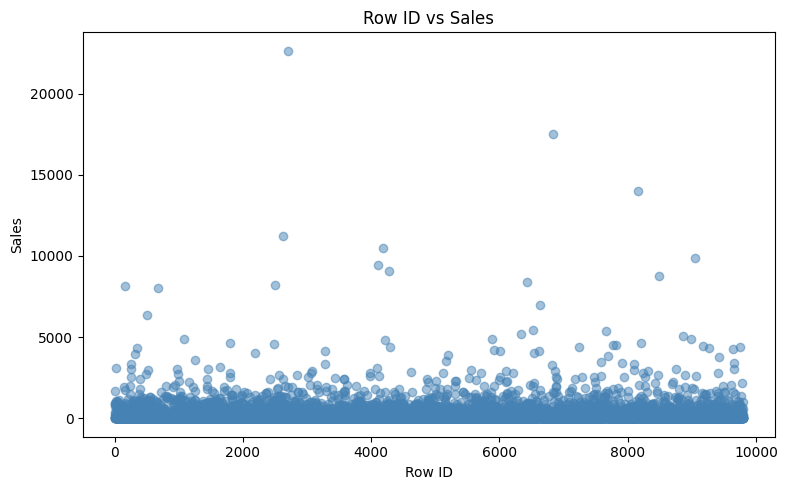

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(df['Row_ID'], df['Sales'], alpha=0.5, color='steelblue')
plt.title('Row ID vs Sales')
plt.xlabel('Row ID')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

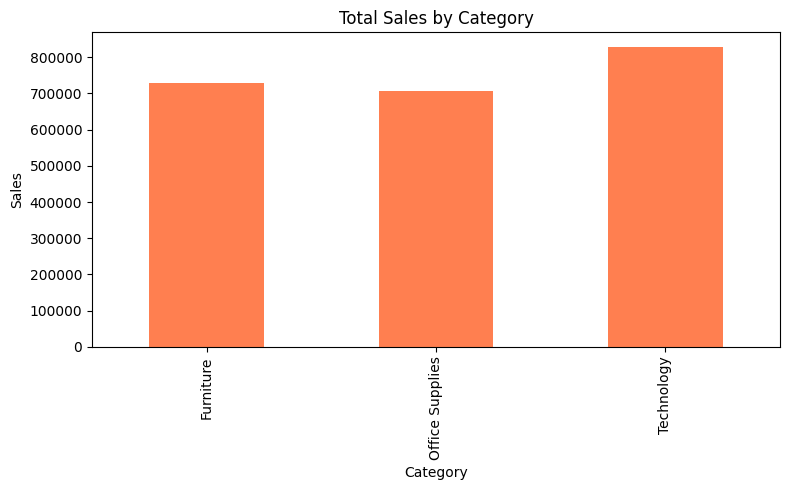

In [30]:
df.groupby('Category')['Sales'].sum().plot(kind='bar', color='coral', figsize=(8,5))
plt.title('Total Sales by Category')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

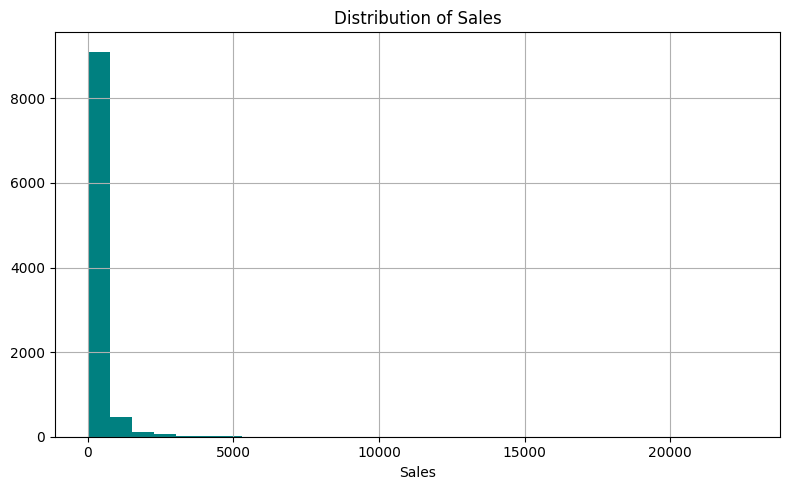

In [31]:
df['Sales'].hist(bins=30, color='teal', figsize=(8,5))
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.tight_layout()
plt.show()

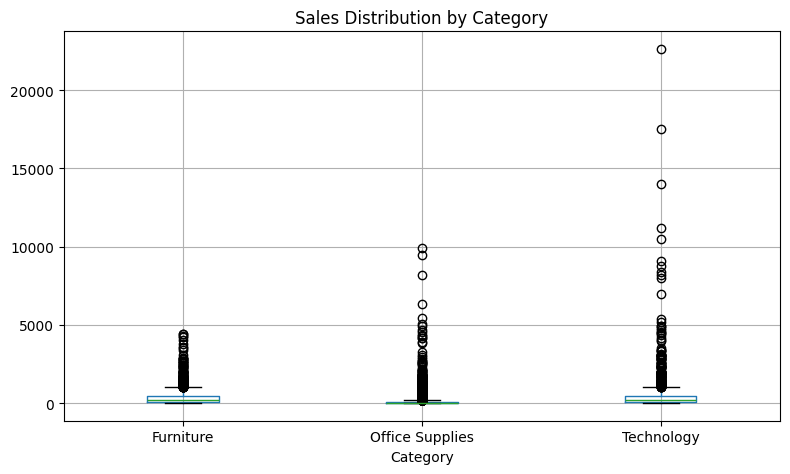

In [32]:
df.boxplot(column='Sales', by='Category', figsize=(8,5))
plt.title('Sales Distribution by Category')
plt.suptitle('')
plt.tight_layout()
plt.show()

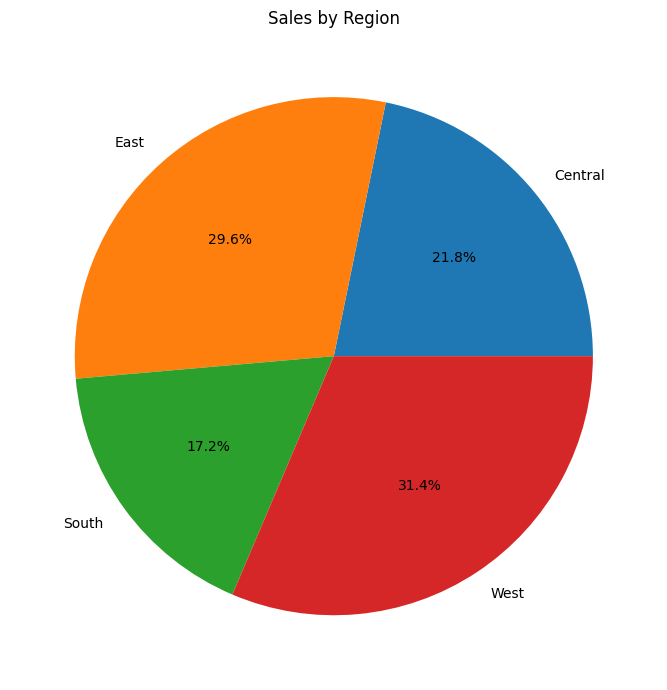

In [33]:
df.groupby('Region')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%', figsize=(7,7))
plt.title('Sales by Region')
plt.ylabel('')
plt.tight_layout()
plt.show()

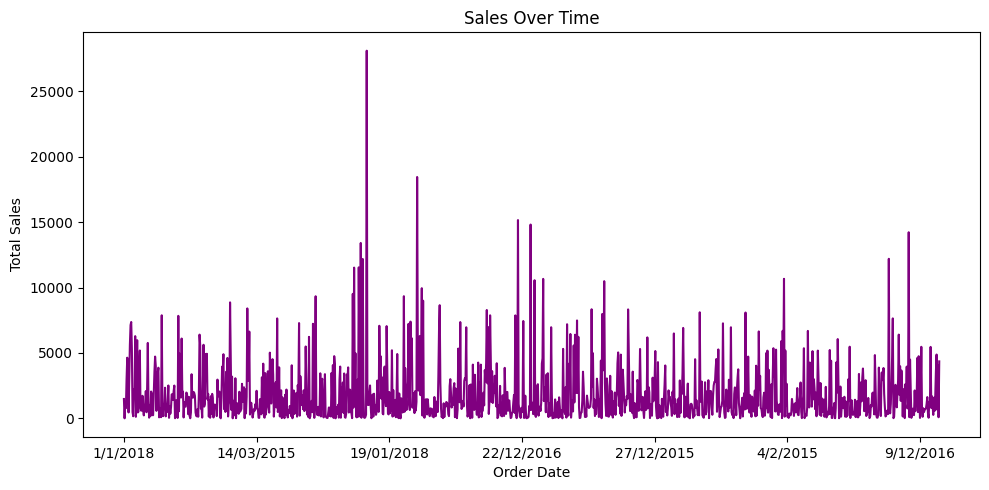

In [34]:
df.groupby('Order_Date')['Sales'].sum().plot(kind='line', figsize=(10,5), color='purple')
plt.title('Sales Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

In [35]:
print("Missing values before:\n")
print(df.isnull().sum())

Missing values before:

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64


In [36]:
df['Sales'].fillna(df['Sales'].mean(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after:\n")
print(df.isnull().sum())

Missing values after:

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64


C:\Users\sarub\AppData\Local\Temp\ipykernel_8212\1197290883.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Sales'].fillna(df['Sales'].mean(), inplace=True)
C:\Users\sarub\AppData\Local\Temp\ipykernel_8212\1197290883.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dty

In [37]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1:   {Q1:.2f}")
print(f"Q3:   {Q3:.2f}")
print(f"IQR:  {IQR:.2f}")

outliers = df[(df['Sales'] < Q1 - 1.5*IQR) | (df['Sales'] > Q3 + 1.5*IQR)]
print(f"\nOutliers found: {len(outliers)}")
print(f"Shape before removing outliers: {df.shape}")

Q1:   17.25
Q3:   210.61
IQR:  193.36

Outliers found: 1145
Shape before removing outliers: (9800, 18)


In [38]:
df_clean = df[(df['Sales'] >= Q1 - 1.5*IQR) & (df['Sales'] <= Q3 + 1.5*IQR)]
print(f"Shape after removing outliers: {df_clean.shape}")
df_clean.head()

Shape after removing outliers: (8655, 18)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.368
5,6,CA-2015-115812,9/6/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860
6,7,CA-2015-115812,9/6/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280


In [39]:
print("Shape before reduction:", df_clean.shape)
df_clean.head()

Shape before reduction: (8655, 18)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.368
5,6,CA-2015-115812,9/6/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860
6,7,CA-2015-115812,9/6/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280


In [40]:
df_sampled = df_clean.sample(frac=0.5, random_state=42)
df_sampled = df_sampled.drop(columns=['Row_ID', 'Postal_Code'], errors='ignore')

print("Shape after reduction:", df_sampled.shape)
df_sampled.head()

Shape after reduction: (4328, 16)


,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
864,CA-2017-134474,5/1/2017,7/1/2017,Second Class,AJ-10795,Anthony Johnson,Corporate,United States,Jacksonville,Florida,South,TEC-PH-10002923,Technology,Phones,Logitech B530 USB Headset - headset - Full siz...,59.184
3591,CA-2015-154186,13/12/2015,15/12/2015,Second Class,RA-19285,Ralph Arnett,Consumer,United States,Houston,Texas,Central,OFF-SU-10001574,Office Supplies,Supplies,Acme Value Line Scissors,2.920
7815,US-2018-109316,8/6/2018,10/6/2018,First Class,MG-17680,Maureen Gastineau,Home Office,United States,Los Angeles,California,West,TEC-PH-10000307,Technology,Phones,Shocksock Galaxy S4 Armband,17.520
7082,CA-2017-106950,2/9/2017,6/9/2017,Standard Class,JE-15715,Joe Elijah,Consumer,United States,Charlotte,North Carolina,South,OFF-BI-10003166,Office Supplies,Binders,GBC Plasticlear Binding Covers,17.220
8756,CA-2017-114307,22/07/2017,26/07/2017,Standard Class,MF-17665,Maureen Fritzler,Corporate,United States,Columbia,Maryland,East,OFF-AP-10002350,Office Supplies,Appliances,Belkin F9H710-06 7 Outlet SurgeMaster Surge Pr...,37.680


In [41]:
from sklearn.preprocessing import MinMaxScaler

print("Before scaling:")
print(df_sampled[['Sales']].head())

Before scaling:
       Sales
864   59.184
3591   2.920
7815  17.520
7082  17.220
8756  37.680


In [42]:
scaler = MinMaxScaler()
df_sampled = df_sampled.copy()
df_sampled['Sales_scaled'] = scaler.fit_transform(df_sampled[['Sales']])

print("After scaling:")
print(df_sampled[['Sales', 'Sales_scaled']].head())

After scaling:
       Sales  Sales_scaled
864   59.184      0.117484
3591   2.920      0.004737
7815  17.520      0.033994
7082  17.220      0.033393
8756  37.680      0.074393


In [43]:
df_sampled['Sales_category'] = pd.cut(df_sampled['Sales'], bins=3, labels=['Low', 'Medium', 'High'])
print(df_sampled['Sales_category'].value_counts())
df_sampled[['Sales', 'Sales_category']].head(10)

Sales_category
Low       3443
Medium     602
High       283
Name: count, dtype: int64


,Sales,Sales_category
864,59.184,Low
3591,2.920,Low
7815,17.520,Low
7082,17.220,Low
8756,37.680,Low
9167,241.440,Medium
1801,4.180,Low
560,84.056,Low
8191,187.760,Medium
5224,166.440,Low


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   str    
 2   Order_Date     9800 non-null   str    
 3   Ship_Date      9800 non-null   str    
 4   Ship_Mode      9800 non-null   str    
 5   Customer_ID    9800 non-null   str    
 6   Customer_Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product_ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub_Category   9800 non-null   str    
 16  Product_Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [45]:
df.describe()

,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [46]:
print("Min:   ", df['Sales'].min())
print("Max:   ", df['Sales'].max())
print("Mean:  ", round(df['Sales'].mean(), 2))
print("Median:", df['Sales'].median())
print("Mode:  ", df['Sales'].mode()[0])

Min:    0.444
Max:    22638.48
Mean:   230.77
Median: 54.489999999999995
Mode:   12.96


In [47]:
print("Range:   ", round(df['Sales'].max() - df['Sales'].min(), 2))
print("Q1:      ", df['Sales'].quantile(0.25))
print("Q3:      ", df['Sales'].quantile(0.75))
print("IQR:     ", round(df['Sales'].quantile(0.75) - df['Sales'].quantile(0.25), 2))
print("Variance:", round(df['Sales'].var(), 2))
print("Std Dev: ", round(df['Sales'].std(), 2))

Range:    22638.04
Q1:       17.248
Q3:       210.60500000000002
IQR:      193.36
Variance: 392692.57
Std Dev:  626.65


          Row_ID     Sales
Row_ID  1.000000  0.001151
Sales   0.001151  1.000000


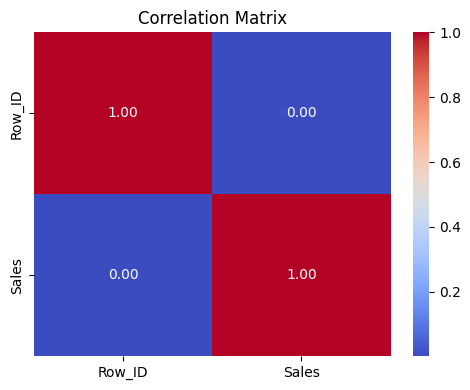

In [48]:
corr_matrix = df[['Row_ID', 'Sales']].corr()
print(corr_matrix)

plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()